# One-Shot Learning mit Siamesischen Netzwerken – Omniglot Datensatz


## Ziel
Ziel dieser Übung ist das Verständnis und die Umsetzung des **One-Shot Learning-Konzepts** anhand eines Bilderkennungsproblems mit minimalen Trainingsdaten.

Wir verwenden den **Omniglot-Datensatz** (handgeschriebene Zeichen aus 50 verschiedenen Alphabeten) und trainieren ein **Siamesisches Netzwerk**, das lernt, Ähnlichkeiten zwischen Bildern zu messen. Dadurch kann es neue Zeichenklassen korrekt klassifizieren, nachdem es **nur ein einziges Beispiel** pro Klasse gesehen hat.

---

## Überblick der Schritte
1. **Vorbereitung** – Datensatz laden & erkunden
2. **Datenaufteilung** – Trainings-, Validierungs- und Testklassen trennen
3. **Datengenerator** – Bildpaare für das Siamese Network erstellen
4. **Modellentwicklung** – Siamese Network mit CNN implementieren
5. **Training** – Modell trainieren & Validierung überwachen
6. **One-Shot Evaluation** – Genauigkeit auf neuen Klassen messen
7. **Analyse & Visualisierung** – Ergebnisse verstehen & diskutieren
8. **Vergleich mit N-Shot Learning** – Erweiterung

---
## Schritt 0: GPU-Prüfung & Pakete installieren

Zuerst prüfen wir, ob eine GPU verfügbar ist (in Google Colab unter *Runtime → Change runtime type → GPU* aktivieren).

In [1]:
import tensorflow as tf

# Prüfe ob GPU verfügbar ist
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU verfügbar: {gpus[0].name}")
else:
    print("Keine GPU gefunden. Training läuft auf CPU (langsamer).")

print(f"TensorFlow Version: {tf.__version__}")

GPU verfügbar: /physical_device:GPU:0
TensorFlow Version: 2.20.0


---
## Schritt 1: Imports & Reproduzierbarkeit

Wir importieren alle benötigten Bibliotheken und setzen zufällige Seeds, damit die Ergebnisse reproduzierbar sind.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import random
import os
import zipfile
import urllib.request
import seaborn as sns
from PIL import Image
from pathlib import Path

# ─── Reproduzierbarkeit ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Alle Imports erfolgreich geladen.")

Alle Imports erfolgreich geladen.


---
## Schritt 2: Omniglot-Datensatz laden

Der **Omniglot-Datensatz** enthält handgeschriebene Zeichen aus **50 verschiedenen Alphabeten** (griechisch, tibetisch, japanisch, etc.) mit insgesamt ~1600 Zeichenklassen. Jede Klasse enthält 20 Beispiele (von verschiedenen Personen gezeichnet).

Er wird direkt von GitHub heruntergeladen – dem offiziellen Repository des Omniglot-Datensatzes.

In [4]:
# ─── Omniglot Datensatz herunterladen ────────────────────────────────────────
# Quelle: https://github.com/brendenlake/omniglot

DATA_DIR = Path("omniglot_data")

URLS = {
    "images_background": "https://github.com/brendenlake/omniglot/raw/master/python/images_background.zip",
    "images_evaluation": "https://github.com/brendenlake/omniglot/raw/master/python/images_evaluation.zip",
}

def download_omniglot(data_dir: Path):
    """Lädt den Omniglot-Datensatz herunter und entpackt ihn."""
    data_dir.mkdir(exist_ok=True)

    for name, url in URLS.items():
        zip_path = data_dir / f"{name}.zip"
        extract_path = data_dir / name

        if extract_path.exists():
            print(f"{name} bereits vorhanden, überspringe Download.")
            continue

        print(f"  Lade {name} herunter...")
        urllib.request.urlretrieve(url, zip_path)

        print(f"  Entpacke {name}...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(data_dir)

        zip_path.unlink()  # Zip-Datei löschen
        print(f"  {name} fertig.")

download_omniglot(DATA_DIR)

  Lade images_background herunter...
  Entpacke images_background...
  images_background fertig.
  Lade images_evaluation herunter...
  Entpacke images_evaluation...
  images_evaluation fertig.


In [5]:
# ─── Datensatz einlesen ───────────────────────────────────────────────────────
# Wir lesen alle Bilder ein und erstellen eine Klassen-Index-Struktur.
# Jede Klasse = ein Unterordner (z.B. Alphabet_X/character01/)

IMG_SIZE = 105  # Omniglot Standardgröße

def load_omniglot_classes(split_dir: Path, img_size=IMG_SIZE):
    """
    Lädt alle Zeichenklassen aus einem Omniglot-Split (background oder evaluation).
    Gibt ein Dictionary zurück: {class_name: np.array (N, H, W, 1)}
    """
    class_dict = {}  # {class_label: [images]}

    for alphabet_dir in sorted(split_dir.iterdir()):
        if not alphabet_dir.is_dir():
            continue
        for char_dir in sorted(alphabet_dir.iterdir()):
            if not char_dir.is_dir():
                continue
            images = []
            for img_path in sorted(char_dir.glob("*.png")):
                img = Image.open(img_path).convert('L')       # Graustufen
                img = img.resize((img_size, img_size))
                arr = np.array(img, dtype=np.float32) / 255.0
                # Omniglot: weißer Hintergrund → invertieren für bessere Konvergenz
                arr = 1.0 - arr
                images.append(arr)
            if images:
                class_name = f"{alphabet_dir.name}/{char_dir.name}"
                class_dict[class_name] = np.array(images)[..., np.newaxis]  # → (N,H,W,1)

    return class_dict

print(" Lade Background-Split (Trainingsklassen)...")
background_classes = load_omniglot_classes(DATA_DIR / "images_background")
print(f"  → {len(background_classes)} Klassen geladen")

print(" Lade Evaluation-Split (Testklassen)...")
evaluation_classes = load_omniglot_classes(DATA_DIR / "images_evaluation")
print(f"  → {len(evaluation_classes)} Klassen geladen")

print(f"\n Gesamtklassen: {len(background_classes) + len(evaluation_classes)}")
print(f" Bildgröße: {IMG_SIZE}×{IMG_SIZE} px, Kanäle: 1 (Graustufen)")

# Beispiel: Bilder pro Klasse
first_key = list(background_classes.keys())[0]
print(f"  Beispiel: Klasse '{first_key}' → {background_classes[first_key].shape[0]} Bilder")

 Lade Background-Split (Trainingsklassen)...
  → 964 Klassen geladen
 Lade Evaluation-Split (Testklassen)...
  → 659 Klassen geladen

 Gesamtklassen: 1623
 Bildgröße: 105×105 px, Kanäle: 1 (Graustufen)
  Beispiel: Klasse 'Alphabet_of_the_Magi/character01' → 20 Bilder


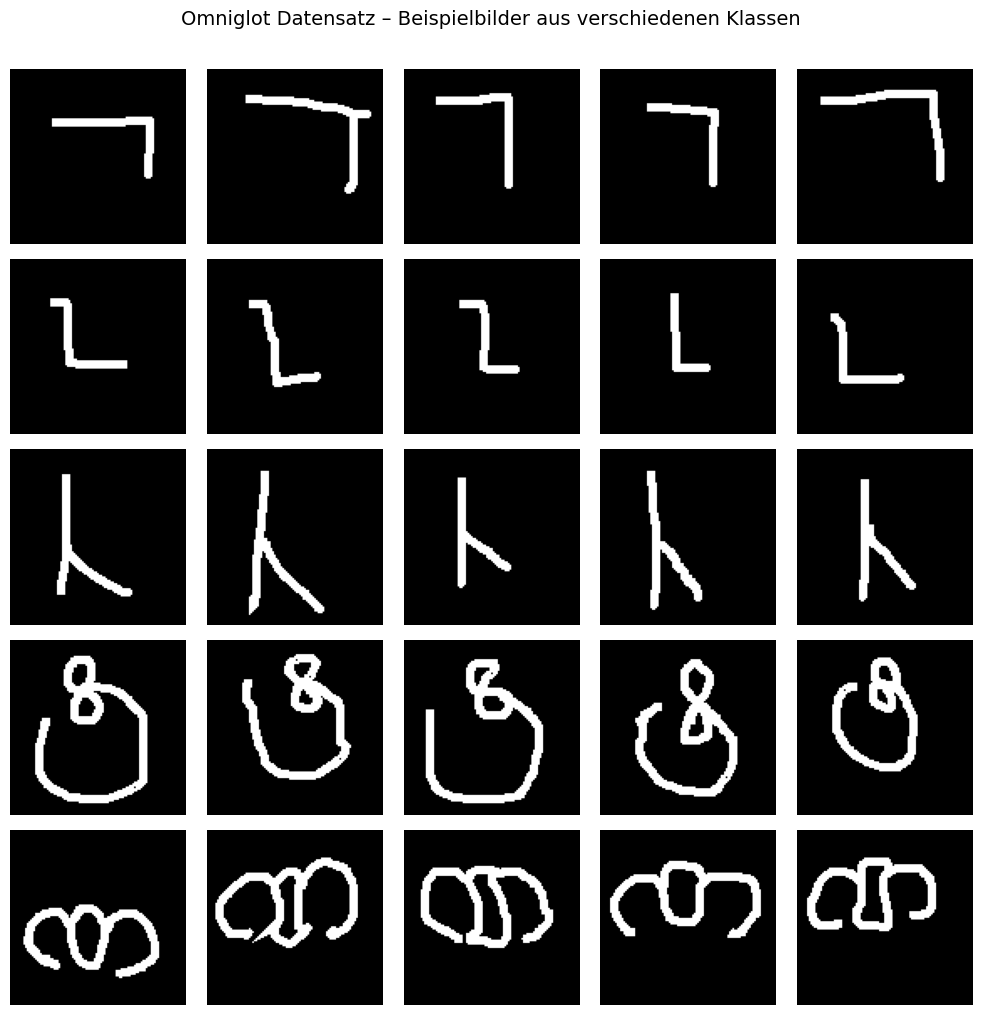

Jede Zeile = eine Zeichenklasse (aus einem anderen Alphabet). Jede Spalte = anderes Beispiel der gleichen Klasse.


In [6]:
# ─── Datensatz visualisieren ─────────────────────────────────────────────────
# Wir zeigen je 5 Beispiele aus 5 verschiedenen Klassen

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("Omniglot Datensatz – Beispielbilder aus verschiedenen Klassen", fontsize=14, y=1.01)

sample_classes = random.sample(list(background_classes.keys()), 5)

for row, cls in enumerate(sample_classes):
    imgs = background_classes[cls]  # Shape: (20, 105, 105, 1)
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(imgs[col].squeeze(), cmap='gray')
        if col == 0:
            ax.set_ylabel(cls.split('/')[0][:12], fontsize=7, rotation=0, labelpad=50, va='center')
        ax.axis('off')

plt.tight_layout()
plt.savefig("01_omniglot_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Jede Zeile = eine Zeichenklasse (aus einem anderen Alphabet). Jede Spalte = anderes Beispiel der gleichen Klasse.")

---
## Schritt 3: Datenaufteilung – Trainings-, Validierungs- und Testklassen

**Wichtig bei One-Shot Learning:** Die Test-Klassen dürfen dem Modell während des Trainings **nie** begegnet sein!  
Wir teilen daher **auf Klassen-Ebene** auf:

| Split | Herkunft | Klassen | Verwendung |
|-------|----------|---------|------------|
| Training | Background | 20 zufällige | Bildpaare erzeugen, Netzwerk trainieren |
| Validierung | Background | restliche | Overfitting überwachen |
| Test | Evaluation | 5 neue | One-Shot Evaluation |

→ Gemäß Angabe: **20 Trainingsklassen, 5 Testklassen** (neue Zeichenklassen).

In [8]:
# ─── Klassen aufteilen ────────────────────────────────────────────────────────
# Gemäß Aufgabenstellung: 20 Trainingsklassen, 5 Testklassen

N_TRAIN_CLASSES = 20    # Zeichenklassen für Training
N_TEST_CLASSES  = 5     # NEUE Klassen für One-Shot Evaluation

# Trainings- und Validierungsklassen aus Background-Split
all_bg_keys = list(background_classes.keys())
random.shuffle(all_bg_keys)

train_class_keys = all_bg_keys[:N_TRAIN_CLASSES]
val_class_keys   = all_bg_keys[N_TRAIN_CLASSES:N_TRAIN_CLASSES + 10]  # 10 für Validierung

# Testklassen aus Evaluation-Split (völlig neue Alphabete!)
all_eval_keys = list(evaluation_classes.keys())
random.shuffle(all_eval_keys)
test_class_keys = all_eval_keys[:N_TEST_CLASSES]

print(f"Datenaufteilung:")
print(f"   Trainingsklassen:    {len(train_class_keys):3d} (aus Background-Split)")
print(f"   Validierungsklassen: {len(val_class_keys):3d} (aus Background-Split)")
print(f"   Testklassen:         {len(test_class_keys):3d} (aus Evaluation-Split = NEUE Klassen!)")
print()
print("Trainingsklassen (Auszug):", train_class_keys[:3])
print("Testklassen:              ", test_class_keys)

# Daten extrahieren
def extract_data(class_keys, class_dict):
    """Gibt (images, labels) Arrays zurück für eine Liste von Klassen-Keys."""
    images_list, labels_list = [], []
    for label_idx, key in enumerate(class_keys):
        imgs = class_dict[key]  # (N, H, W, 1)
        images_list.append(imgs)
        labels_list.extend([label_idx] * len(imgs))
    return np.concatenate(images_list, axis=0), np.array(labels_list)

X_train, y_train = extract_data(train_class_keys, background_classes)
X_val,   y_val   = extract_data(val_class_keys,   background_classes)
X_test,  y_test  = extract_data(test_class_keys,  evaluation_classes)

print(f"\n Datensatz-Dimensionen:")
print(f"   X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Datenaufteilung:
   Trainingsklassen:     20 (aus Background-Split)
   Validierungsklassen:  10 (aus Background-Split)
   Testklassen:           5 (aus Evaluation-Split = NEUE Klassen!)

Trainingsklassen (Auszug): ['Braille/character01', 'Syriac_(Estrangelo)/character04', 'Inuktitut_(Canadian_Aboriginal_Syllabics)/character09']
Testklassen:               ['Manipuri/character28', 'Aurek-Besh/character14', 'Ge_ez/character24', 'ULOG/character14', 'Oriya/character25']

 Datensatz-Dimensionen:
   X_train: (400, 105, 105, 1)  y_train: (400,)
   X_val:   (200, 105, 105, 1)    y_val:   (200,)
   X_test:  (100, 105, 105, 1)   y_test:  (100,)


---
## Schritt 4: Bildpaare für das Siamese Network erstellen

Ein **Siamesisches Netzwerk** wird mit **Paaren von Bildern** trainiert:
- **Positive Paare (Label = 1):** Zwei Bilder aus der **gleichen** Klasse → Netzwerk soll hohe Ähnlichkeit ausgeben
- **Negative Paare (Label = 0):** Zwei Bilder aus **verschiedenen** Klassen → Netzwerk soll geringe Ähnlichkeit ausgeben

Das Netzwerk lernt dadurch eine **Ähnlichkeitsfunktion** – keine feste Klasseneinteilung!

In [9]:
# ─── Bildpaare generieren ─────────────────────────────────────────────────────

def generate_pairs(X, y, num_pairs=5000):
    """
    Erstellt balancierte Paare von Bildern für das Siamese Network Training.

    Args:
        X: Bilder-Array (N, H, W, 1)
        y: Labels (N,)
        num_pairs: Anzahl der zu erzeugenden Paare

    Returns:
        pairs:  np.array (num_pairs, 2, H, W, 1)
        labels: np.array (num_pairs,) – 1 = gleiche Klasse, 0 = verschiedene Klassen
    """
    unique_classes = np.unique(y)
    # Index: Klasse → Bildindizes
    class_indices = {c: np.where(y == c)[0] for c in unique_classes}

    pairs, labels = [], []

    for i in range(num_pairs):
        if i % 2 == 0:
            # ── Positives Paar: gleiche Klasse ──
            cls = random.choice(unique_classes)
            idx1, idx2 = random.sample(list(class_indices[cls]), 2)
            pairs.append([X[idx1], X[idx2]])
            labels.append(1)
        else:
            # ── Negatives Paar: verschiedene Klassen ──
            cls1, cls2 = random.sample(list(unique_classes), 2)
            idx1 = random.choice(class_indices[cls1])
            idx2 = random.choice(class_indices[cls2])
            pairs.append([X[idx1], X[idx2]])
            labels.append(0)

    return np.array(pairs, dtype=np.float32), np.array(labels, dtype=np.float32)

N_TRAIN_PAIRS = 10000
N_VAL_PAIRS   = 2000

print(f"Generiere {N_TRAIN_PAIRS} Trainingspaare...")
train_pairs, train_labels = generate_pairs(X_train, y_train, N_TRAIN_PAIRS)

print(f"Generiere {N_VAL_PAIRS} Validierungspaare...")
val_pairs, val_labels = generate_pairs(X_val, y_val, N_VAL_PAIRS)

print(f"\nPaare erstellt:")
print(f"   train_pairs Shape: {train_pairs.shape}")
print(f"   Positive (gleich): {train_labels.sum():.0f} | Negative (verschieden): {(1-train_labels).sum():.0f}")

Generiere 10000 Trainingspaare...
Generiere 2000 Validierungspaare...

Paare erstellt:
   train_pairs Shape: (10000, 2, 105, 105, 1)
   Positive (gleich): 5000 | Negative (verschieden): 5000


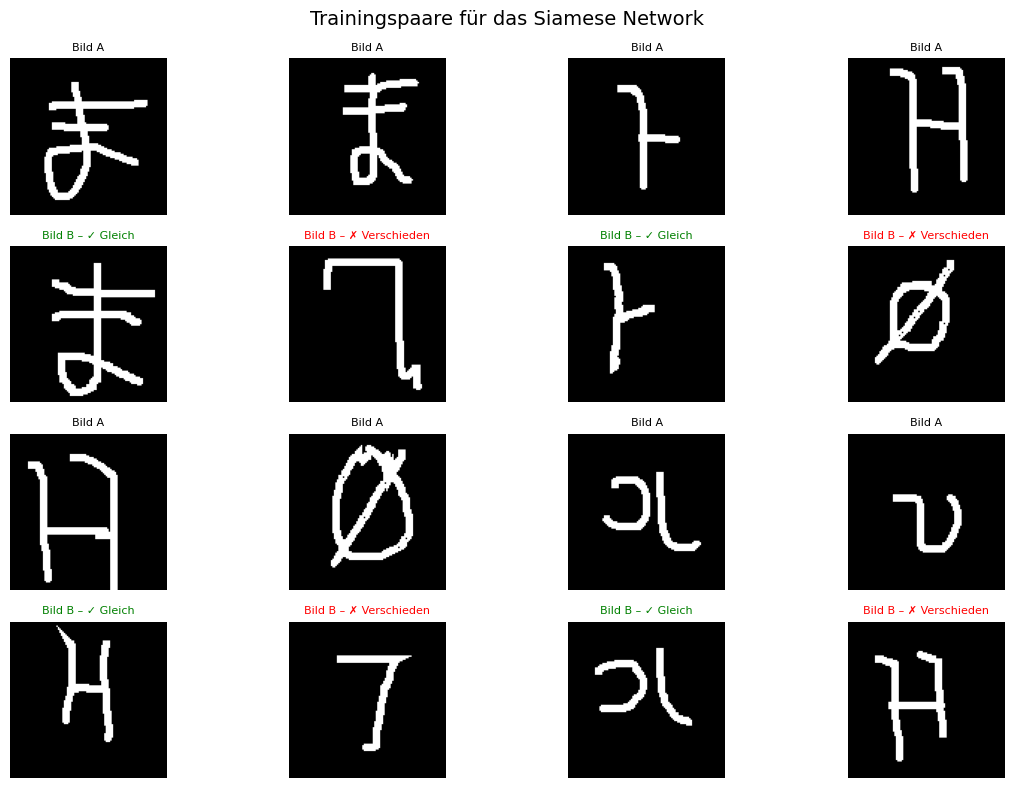

Grün = positives Paar (gleiche Klasse), Rot = negatives Paar (verschiedene Klassen)


In [10]:
# ─── Paare visualisieren ──────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
fig.suptitle("Trainingspaare für das Siamese Network", fontsize=14)

for i in range(8):
    img1 = train_pairs[i, 0].squeeze()
    img2 = train_pairs[i, 1].squeeze()
    label = int(train_labels[i])
    color = 'green' if label == 1 else 'red'
    title = "✓ Gleich" if label == 1 else "✗ Verschieden"

    axes[i // 4 * 2, i % 4].imshow(img1, cmap='gray')
    axes[i // 4 * 2, i % 4].set_title(f"Bild A", fontsize=8)
    axes[i // 4 * 2, i % 4].axis('off')

    axes[i // 4 * 2 + 1, i % 4].imshow(img2, cmap='gray')
    axes[i // 4 * 2 + 1, i % 4].set_title(f"Bild B – {title}", fontsize=8, color=color)
    axes[i // 4 * 2 + 1, i % 4].axis('off')

plt.tight_layout()
plt.savefig("02_training_pairs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grün = positives Paar (gleiche Klasse), Rot = negatives Paar (verschiedene Klassen)")

---
## Schritt 5: Siamese Network implementieren

### Architektur

Das **Siamese Network** besteht aus zwei identischen CNNs mit **geteilten Gewichten** (Shared Weights):

```
Bild A ──► CNN ──► Embedding A ──┐
                                  ├──► L1-Distanz ──► Sigmoid ──► Ähnlichkeit [0,1]
Bild B ──► CNN ──► Embedding B ──┘
  (gleiche Gewichte!)
```

- **Verlustfunktion:** Binary Crossentropy (1 = gleich, 0 = verschieden)
- **Distanzmetrik:** L1-Distanz (Betrag der Differenz der Embeddings)

In [11]:
# ─── CNN Basis-Netzwerk (Shared Weights) ────────────────────────────────────

def create_base_network(input_shape):
    """
    Das Basis-CNN, das aus einem Bild einen Embedding-Vektor extrahiert.
    Beide 'Zwillinge' im Siamese Network teilen exakt diese Gewichte.

    Architektur:
    Conv(64) → Pool → Conv(128) → Pool → Conv(128) → Pool → Flatten → Dense(256)
    """
    inputs = layers.Input(shape=input_shape)

    # Block 1: Niedrige Features (Kanten, Ecken)
    x = layers.Conv2D(64, (10, 10), activation='relu', padding='valid')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Block 2: Mittlere Features (Kurven, Bögen)
    x = layers.Conv2D(128, (7, 7), activation='relu', padding='valid')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Block 3: Hohe Features (Zeichenstruktur)
    x = layers.Conv2D(128, (4, 4), activation='relu', padding='valid')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Block 4: Abstrakte Features
    x = layers.Conv2D(256, (4, 4), activation='relu', padding='valid')(x)

    # Flach machen und Dense-Schicht
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='sigmoid')(x)  # Siamese Paper: 4096 sigmoid units

    return models.Model(inputs, x, name="base_cnn")

INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)
base_network = create_base_network(INPUT_SHAPE)
base_network.summary()

Model: "base_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 105, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 42, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,948,928 (148.58 MB)

 Trainable params: 38,948,288 (148.58 MB)

 Non-trainable params: 640 (2.50 KB)

In [12]:
# ─── Vollständiges Siamese Network ───────────────────────────────────────────

def create_siamese_network(input_shape):
    """
    Erstellt das vollständige Siamese Network.

    Beide Eingaben werden durch dasselbe Basis-CNN geleitet (geteilte Gewichte).
    Die L1-Distanz zwischen den Embeddings wird berechnet und durch eine
    Sigmoid-Schicht in eine Ähnlichkeitswahrscheinlichkeit umgewandelt.
    """
    # Beide Eingaben
    left_input  = layers.Input(shape=input_shape, name="image_A")
    right_input = layers.Input(shape=input_shape, name="image_B")

    # Gemeinsames CNN – gleiche Gewichte für beide Eingaben!
    shared_cnn = create_base_network(input_shape)

    embedding_left  = shared_cnn(left_input)
    embedding_right = shared_cnn(right_input)

    # L1-Distanz: Maß für die Unähnlichkeit der Embeddings
    # Kleine Distanz → ähnliche Zeichen | Große Distanz → verschiedene Zeichen
    l1_distance = layers.Lambda(
        lambda tensors: tf.abs(tensors[0] - tensors[1]),
        name="l1_distance"
    )([embedding_left, embedding_right])

    # Finale Vorhersage: Wahrscheinlichkeit, dass beide Bilder zur gleichen Klasse gehören
    output = layers.Dense(1, activation='sigmoid', name="similarity")(l1_distance)

    siamese_model = models.Model(
        inputs=[left_input, right_input],
        outputs=output,
        name="siamese_network"
    )

    return siamese_model, shared_cnn

siamese_model, shared_cnn = create_siamese_network(INPUT_SHAPE)

# ─── Modell kompilieren ───────────────────────────────────────────────────────
# Binary Crossentropy: perfekt für binäre Ähnlichkeit (0/1)
# Adam mit niedriger Lernrate: stabiles Training bei Siamese Networks
siamese_model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.00006),
    metrics=['accuracy']
)

siamese_model.summary()

Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_A             │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_B             │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ base_cnn            │ (None, 4096)      │ 38,948,928 │ image_A[0][0],    │
│ (Functional)        │                   │            │ image_B[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_distance         │ (None, 4096)      │          0 │ base_cnn[0][0],   │
│ (Lambda)            │                   │            │ base_cnn[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similarity (Dense)  │ (None, 1)         │      4,097 │ l1_distance[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,953,025 (148.59 MB)

 Trainable params: 38,952,385 (148.59 MB)

 Non-trainable params: 640 (2.50 KB)

---
## Schritt 6: Training

Wir trainieren das Siamese Network mit den Bildpaaren und überwachen die Leistung auf dem **Validierungsset** nach jeder Epoche.

**Callbacks:**
- `EarlyStopping`: Stoppt das Training wenn sich die Val-Loss nicht mehr verbessert
- `ModelCheckpoint`: Speichert das beste Modell

In [13]:
# ─── Training Callbacks ───────────────────────────────────────────────────────

callbacks = [
    # Speichert das beste Modell basierend auf val_loss
    tf.keras.callbacks.ModelCheckpoint(
        'best_siamese_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Stoppt Training wenn val_loss sich 5 Epochen nicht verbessert
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Lernrate halbieren wenn Plateau erreicht
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# ─── Training starten ─────────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 20  # EarlyStopping greift ggf. früher

print(f"Starte Training...")
print(f"   Batch Size: {BATCH_SIZE} | Epochen: {EPOCHS}")
print(f"   Trainingspaare: {len(train_pairs)} | Validierungspaare: {len(val_pairs)}")
print()

history = siamese_model.fit(
    x=[train_pairs[:, 0], train_pairs[:, 1]],
    y=train_labels,
    validation_data=(
        [val_pairs[:, 0], val_pairs[:, 1]],
        val_labels
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining abgeschlossen!")

Starte Training...
   Batch Size: 32 | Epochen: 20
   Trainingspaare: 10000 | Validierungspaare: 2000

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8595 - loss: 0.3339
Epoch 1: val_loss improved from None to 0.66151, saving model to best_siamese_model.h5



Epoch 1: finished saving model to best_siamese_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 111ms/step - accuracy: 0.9297 - loss: 0.2014 - val_accuracy: 0.6860 - val_loss: 0.6615 - learning_rate: 6.0000e-05
Epoch 2/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9930 - loss: 0.0440
Epoch 2: val_loss improved from 0.66151 to 0.65400, saving model to best_siamese_model.h5



Epoch 2: finished saving model to best_siamese_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9956 - loss: 0.0313 - val_accuracy: 0.7140 - val_loss: 0.6540 - learning_rate: 6.0000e-05
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9990 - loss: 0.0110
Epoch 3: val_loss did not improve from 0.65400
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9994 - loss: 0.0087 - val_accuracy: 0.7065 - val_loss: 0.6920 - learning_rate: 6.0000e-05
Epoch 4/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0041
Epoch 4: val_loss did not improve from 0.65400
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.7060 - val_loss: 0.7212 - learning_rate: 6.0000e-05
Epoch 5/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 5: val_loss did not improve from 0.65400

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
313/313 ━━━━━━━━━━━━━━

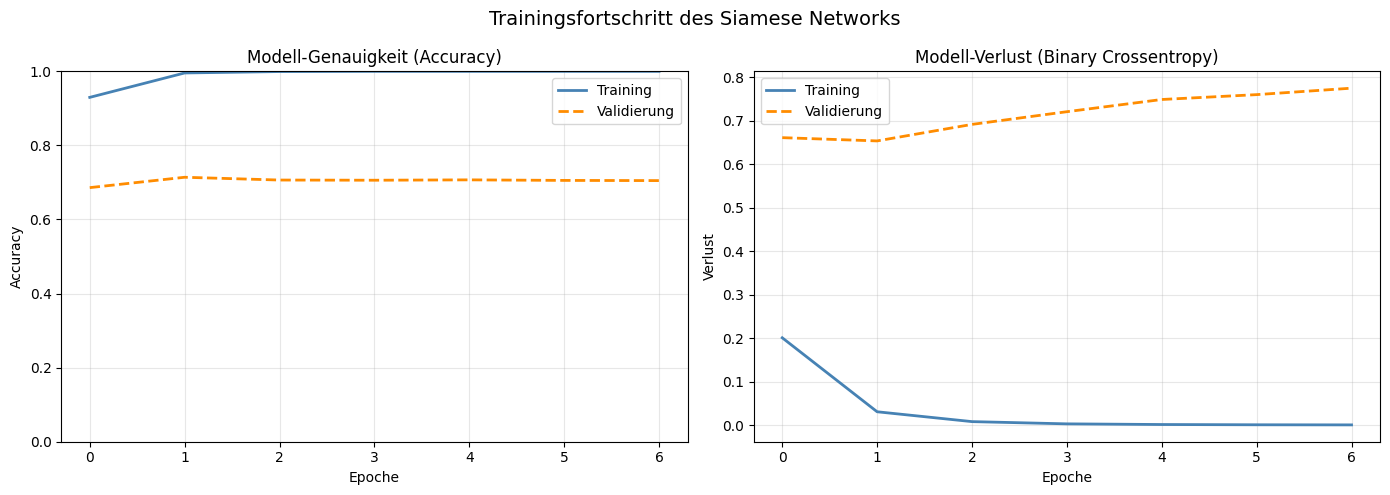

Bestes Ergebnis: Val-Accuracy = 0.7140 | Val-Loss = 0.6540


In [14]:
# ─── Trainingsfortschritt visualisieren ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Trainingsfortschritt des Siamese Networks", fontsize=14)

# Accuracy
ax = axes[0]
ax.plot(history.history['accuracy'],     label='Training',    color='steelblue',  linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validierung', color='darkorange', linewidth=2, linestyle='--')
ax.set_title('Modell-Genauigkeit (Accuracy)')
ax.set_xlabel('Epoche')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# Loss
ax = axes[1]
ax.plot(history.history['loss'],     label='Training',    color='steelblue',  linewidth=2)
ax.plot(history.history['val_loss'], label='Validierung', color='darkorange', linewidth=2, linestyle='--')
ax.set_title('Modell-Verlust (Binary Crossentropy)')
ax.set_xlabel('Epoche')
ax.set_ylabel('Verlust')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_training_history.png", dpi=150, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f"Bestes Ergebnis: Val-Accuracy = {best_val_acc:.4f} | Val-Loss = {best_val_loss:.4f}")

---
## Schritt 7: One-Shot Evaluation

### Testprozess (N-Way One-Shot)

Bei der One-Shot Evaluation wird ein **N-Way One-Shot Task** durchgeführt:
1. Wähle N verschiedene Klassen aus dem **Testset** (die das Modell nie gesehen hat)
2. Wähle **1 Referenzbild** pro Klasse (Support Set)
3. Gib ein **Anfragebild** vor
4. Das Modell vergleicht das Anfragebild mit allen N Referenzbildern
5. Die Klasse mit der **höchsten Ähnlichkeit** gewinnt

→ Bei 5-Way One-Shot liegt die Zufallsrate bei **20%**!

In [15]:
# ─── N-Way One-Shot Task erstellen ───────────────────────────────────────────

def create_one_shot_task(X, y, n_way=5):
    """
    Erstellt einen N-Way One-Shot Task.

    Ablauf:
    - Wähle n_way verschiedene Klassen
    - Pro Klasse: 1 Referenzbild (Support) und 1 Testbild (Query)
    - Gib das Anfragebild und alle Referenzbilder zurück

    Returns:
        query_image:     Das Anfragebild (H, W, 1)
        support_images:  n_way Referenzbilder (n_way, H, W, 1)
        correct_idx:     Index des korrekten Referenzbilds
    """
    unique_classes = np.unique(y)
    selected_classes = np.random.choice(unique_classes, size=n_way, replace=False)

    support_images = []
    query_image    = None
    correct_idx    = np.random.randint(0, n_way)  # Welche Klasse ist die Anfrage?

    for i, cls in enumerate(selected_classes):
        cls_indices = np.where(y == cls)[0]
        chosen = np.random.choice(cls_indices, size=2, replace=False)
        support_images.append(X[chosen[0]])

        if i == correct_idx:
            query_image = X[chosen[1]]  # Zweites Bild der gleichen Klasse als Anfrage

    return query_image, np.array(support_images), correct_idx


def one_shot_accuracy(model, X, y, n_trials=200, n_way=5):
    """
    Berechnet die One-Shot Genauigkeit durch n_trials Tests.

    Für jeden Trial:
    1. Erstelle einen n_way One-Shot Task
    2. Vergleiche das Anfragebild mit jedem Referenzbild
    3. Wähle die Klasse mit der höchsten Ähnlichkeit
    4. Prüfe ob die Vorhersage korrekt ist
    """
    correct = 0

    for _ in range(n_trials):
        query, support_set, correct_idx = create_one_shot_task(X, y, n_way)

        # Anfragebild n_way mal wiederholen (einmal pro Referenzbild)
        query_repeated = np.repeat(query[np.newaxis], n_way, axis=0)  # (n_way, H, W, 1)

        # Ähnlichkeiten berechnen: Anfragebild vs. alle Referenzbilder
        similarities = model.predict(
            [query_repeated, support_set],
            verbose=0
        ).flatten()  # (n_way,)

        # Vorhersage: Index mit höchster Ähnlichkeit
        predicted_idx = np.argmax(similarities)

        if predicted_idx == correct_idx:
            correct += 1

    return correct / n_trials


# ─── One-Shot Genauigkeit berechnen ───────────────────────────────────────────
print("Führe One-Shot Evaluation durch...")
N_TRIALS = 200
N_WAY    = 5

accuracy = one_shot_accuracy(siamese_model, X_test, y_test, n_trials=N_TRIALS, n_way=N_WAY)

print(f"\nOne-Shot Ergebnis:")
print(f"   {N_WAY}-Way One-Shot Genauigkeit: {accuracy*100:.2f}%")
print(f"   Zufallsrate (Baseline):          {100/N_WAY:.2f}%")
print(f"   Verbesserung über Zufall:         +{(accuracy - 1/N_WAY)*100:.2f}%")

Führe One-Shot Evaluation durch...

One-Shot Ergebnis:
   5-Way One-Shot Genauigkeit: 64.00%
   Zufallsrate (Baseline):          20.00%
   Verbesserung über Zufall:         +44.00%


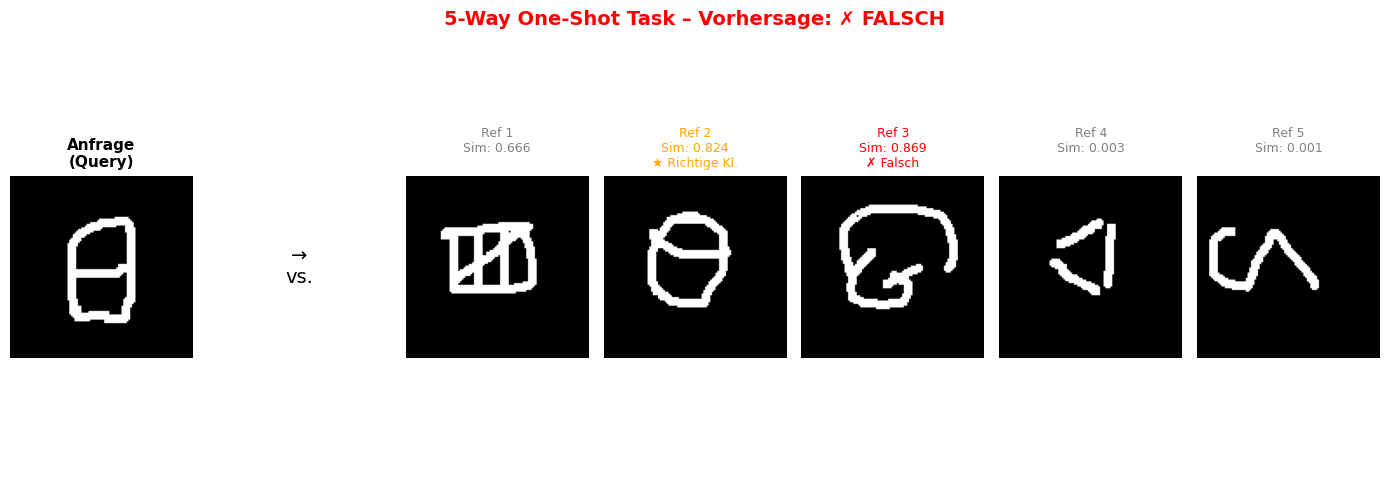

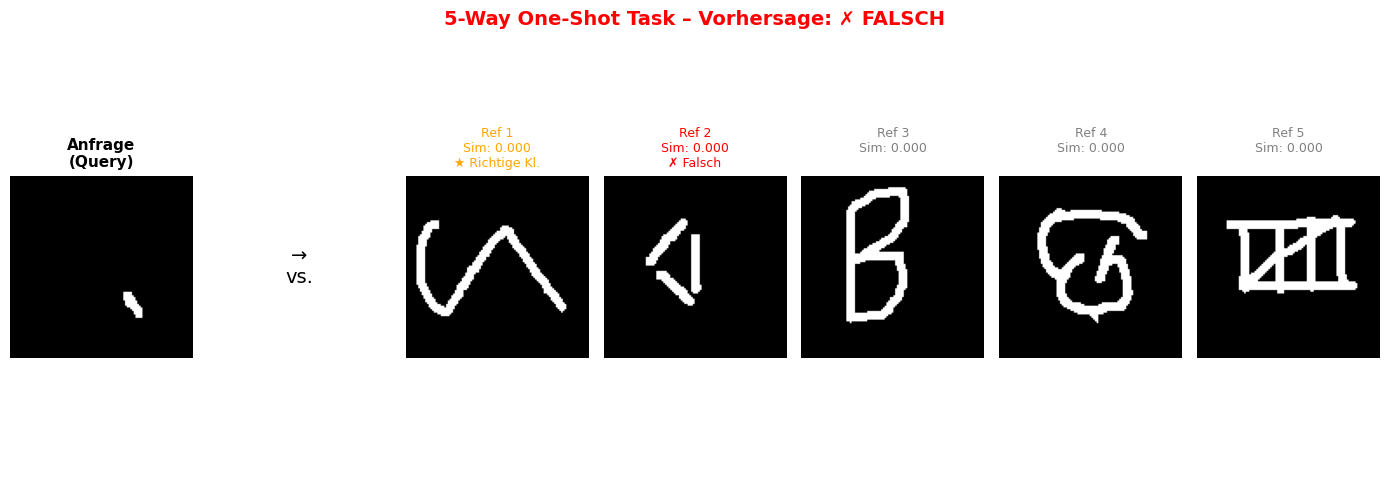

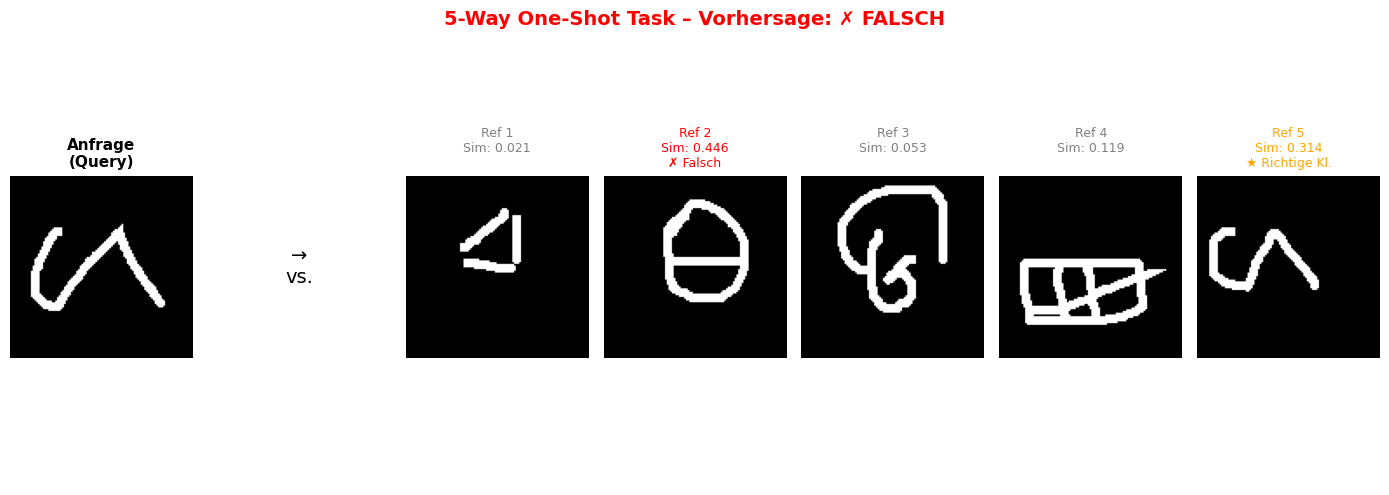

In [16]:
# ─── Einen One-Shot Task visualisieren ────────────────────────────────────────

def visualize_one_shot_task(model, X, y, n_way=5):
    """Zeigt einen One-Shot Task mit Vorhersage und Ähnlichkeiten."""

    query, support_set, correct_idx = create_one_shot_task(X, y, n_way)
    query_repeated = np.repeat(query[np.newaxis], n_way, axis=0)
    similarities   = model.predict([query_repeated, support_set], verbose=0).flatten()
    predicted_idx  = np.argmax(similarities)

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(2, n_way + 2, figure=fig)

    # Anfragebild
    ax_query = fig.add_subplot(gs[:, 0])
    ax_query.imshow(query.squeeze(), cmap='gray')
    ax_query.set_title("Anfrage\n(Query)", fontsize=11, fontweight='bold')
    ax_query.axis('off')

    # Trennlinie (Pfeil)
    ax_arr = fig.add_subplot(gs[:, 1])
    ax_arr.text(0.5, 0.5, '→\nvs.', ha='center', va='center', fontsize=14)
    ax_arr.axis('off')

    # Referenzbilder
    for i in range(n_way):
        ax = fig.add_subplot(gs[:, i + 2])
        ax.imshow(support_set[i].squeeze(), cmap='gray')

        is_correct_class = (i == correct_idx)
        is_predicted     = (i == predicted_idx)

        if is_correct_class and is_predicted:
            color, marker = 'green', '✓ Korrekt'
        elif is_predicted:
            color, marker = 'red', '✗ Falsch'
        elif is_correct_class:
            color, marker = 'orange', '★ Richtige Kl.'
        else:
            color, marker = 'gray', ''

        ax.set_title(f"Ref {i+1}\nSim: {similarities[i]:.3f}\n{marker}",
                     fontsize=9, color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3 if (is_correct_class or is_predicted) else 1)
        ax.axis('off')

    verdict = "✓ KORREKT" if predicted_idx == correct_idx else "✗ FALSCH"
    color   = 'green' if predicted_idx == correct_idx else 'red'
    fig.suptitle(f"5-Way One-Shot Task – Vorhersage: {verdict}",
                 fontsize=14, fontweight='bold', color=color)

    plt.tight_layout()
    plt.savefig("04_one_shot_task.png", dpi=150, bbox_inches='tight')
    plt.show()

# Mehrere Tasks zeigen
for _ in range(3):
    visualize_one_shot_task(siamese_model, X_test, y_test, n_way=N_WAY)

---
## Schritt 8: Analyse & Visualisierung

### 8a) Feature Space Visualisierung mit PCA

Wir visualisieren den gelernten **Embedding-Raum** des Basis-CNNs mit PCA (2D-Projektion). Wenn das Netzwerk gut trainiert ist, sollten Bilder der gleichen Klasse **nahe beieinanderliegen** und Bilder verschiedener Klassen **weit entfernt** sein.

🔍 Berechne Embeddings für Testbilder...
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
PCA erklärt 40.6% der Varianz


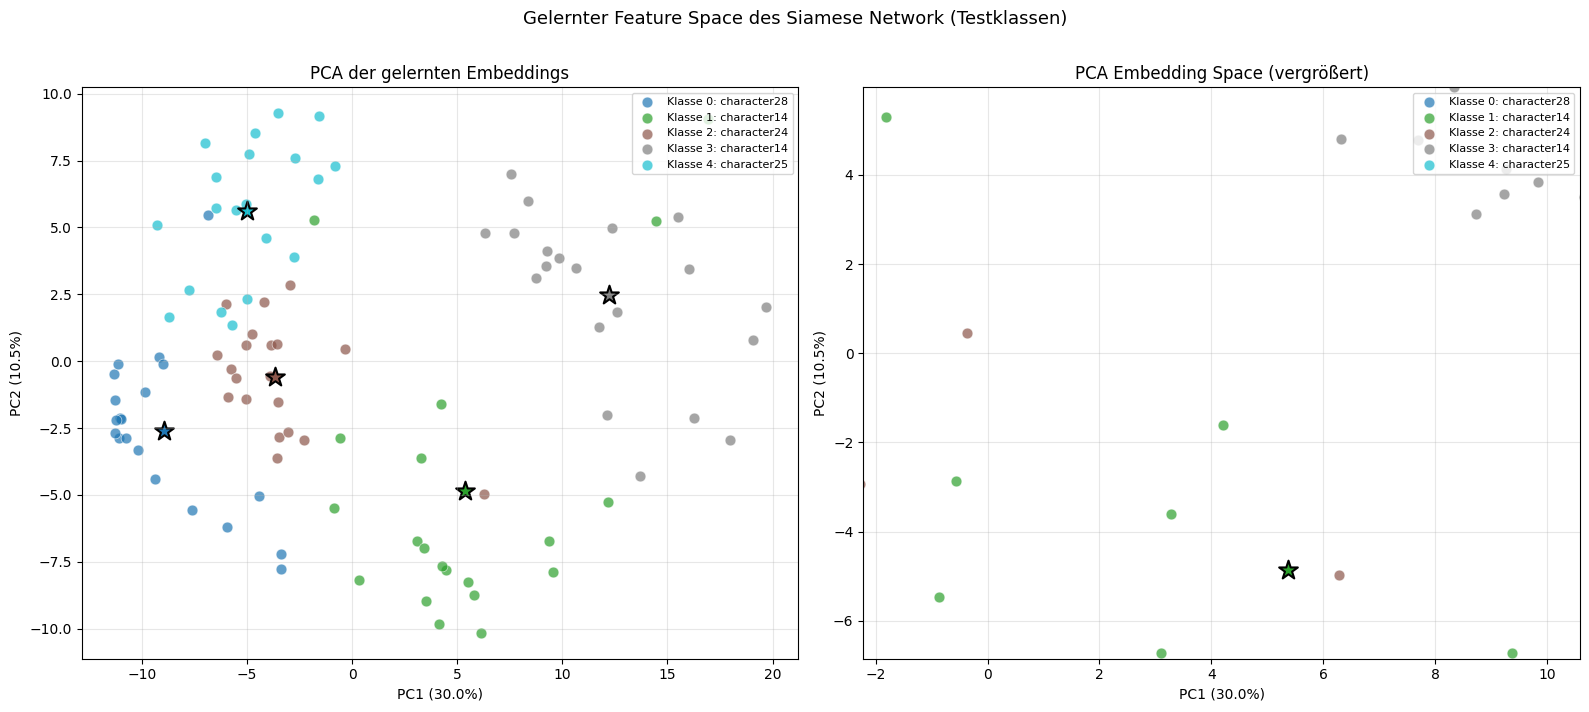

★ = Klassenzentrum | Punkte der gleichen Farbe = gleiche Klasse


In [17]:
# ─── Feature Space Visualisierung (PCA) ──────────────────────────────────────

# Testbilder durch das Basis-CNN schicken → Embeddings
print("🔍 Berechne Embeddings für Testbilder...")
test_embeddings = shared_cnn.predict(X_test, verbose=1, batch_size=64)

# PCA: Dimensionsreduktion von 4096 → 2
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(test_embeddings)

print(f"PCA erklärt {pca.explained_variance_ratio_.sum()*100:.1f}% der Varianz")

# Farben pro Klasse
colors = plt.cm.tab10(np.linspace(0, 1, N_TEST_CLASSES))
class_names = [k.split('/')[1] for k in test_class_keys]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (ax, title) in enumerate(zip(axes, ["PCA der gelernten Embeddings", "PCA Embedding Space (vergrößert)"])):
    for i in range(N_TEST_CLASSES):
        mask = y_test == i
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=f"Klasse {i}: {class_names[i]}",
            alpha=0.7,
            s=60,
            edgecolors='white',
            linewidths=0.5
        )
        # Klassenzentrum markieren
        center = embeddings_2d[mask].mean(axis=0)
        ax.scatter(*center, c=[colors[i]], s=200, marker='*', edgecolors='black', linewidths=1.5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

    if ax_idx == 1:  # Zweites Plot etwas vergrößern
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        cx, cy = np.mean(xlim), np.mean(ylim)
        r = min(xlim[1]-xlim[0], ylim[1]-ylim[0]) * 0.3
        ax.set_xlim(cx - r, cx + r)
        ax.set_ylim(cy - r, cy + r)

plt.suptitle("Gelernter Feature Space des Siamese Network (Testklassen)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("05_feature_space_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("★ = Klassenzentrum | Punkte der gleichen Farbe = gleiche Klasse")

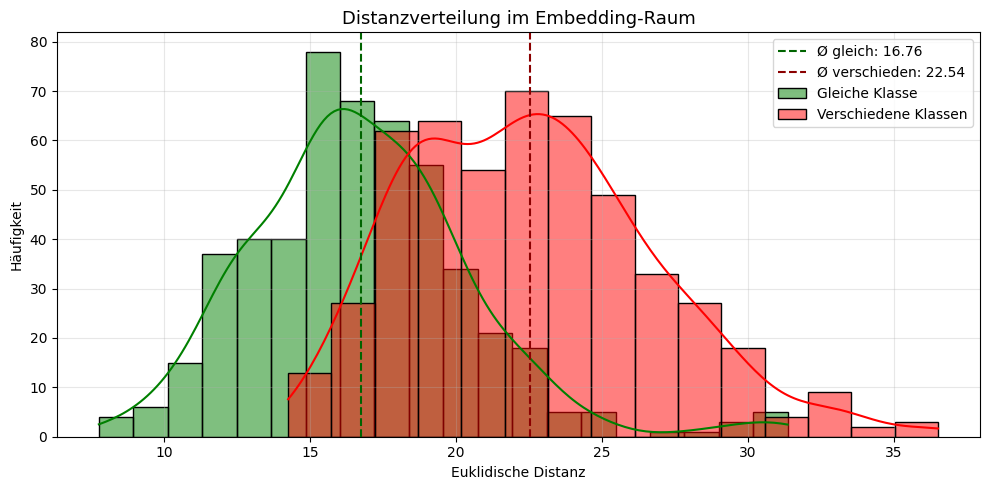

Je größer die Trennung zwischen grün und rot, desto besser das Modell!


In [18]:
# ─── Distanzverteilung visualisieren ──────────────────────────────────────────
# Wir zeigen, wie gut das Netzwerk gleiche von verschiedenen Klassen trennt

same_class_dists, diff_class_dists = [], []
N_DIST_SAMPLES = 500

for _ in range(N_DIST_SAMPLES):
    unique_classes = np.unique(y_test)

    # Gleiche Klasse
    cls = random.choice(unique_classes)
    idx1, idx2 = random.sample(list(np.where(y_test == cls)[0]), 2)
    d = np.linalg.norm(test_embeddings[idx1] - test_embeddings[idx2])
    same_class_dists.append(d)

    # Verschiedene Klassen
    cls1, cls2 = random.sample(list(unique_classes), 2)
    idx1 = random.choice(np.where(y_test == cls1)[0])
    idx2 = random.choice(np.where(y_test == cls2)[0])
    d = np.linalg.norm(test_embeddings[idx1] - test_embeddings[idx2])
    diff_class_dists.append(d)

plt.figure(figsize=(10, 5))
sns.histplot(same_class_dists, kde=True, color='green', alpha=0.5, label='Gleiche Klasse')
sns.histplot(diff_class_dists, kde=True, color='red',   alpha=0.5, label='Verschiedene Klassen')
plt.axvline(np.mean(same_class_dists), color='darkgreen', linestyle='--',
            label=f'Ø gleich: {np.mean(same_class_dists):.2f}')
plt.axvline(np.mean(diff_class_dists), color='darkred',   linestyle='--',
            label=f'Ø verschieden: {np.mean(diff_class_dists):.2f}')
plt.title("Distanzverteilung im Embedding-Raum", fontsize=13)
plt.xlabel("Euklidische Distanz")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("06_distance_distribution.png", dpi=150)
plt.show()
print("Je größer die Trennung zwischen grün und rot, desto besser das Modell!")

---
## Schritt 9: Vergleich mit N-Shot Learning

**Erweiterung gemäß Angabe:** Wie verbessert sich die Genauigkeit, wenn wir mehr als ein Beispiel pro Klasse verwenden? (2-Shot, 5-Shot, 10-Shot)

Bei **N-Shot Learning** haben wir N Referenzbilder pro Klasse. Wir berechnen den Durchschnitts-Embedding aller N Referenzbilder und vergleichen den Query damit.

In [19]:
# ─── N-Shot Evaluation ────────────────────────────────────────────────────────

def n_shot_accuracy(model, base_cnn, X, y, n_shot=1, n_way=5, n_trials=100):
    """
    Berechnet die N-Shot Genauigkeit.

    Bei N-Shot: Wir haben N Referenzbilder pro Klasse.
    Strategie: Mittleres Embedding aus N Referenzbildern berechnen,
    dann Query mit diesen mittleren Embeddings vergleichen.
    """
    correct = 0
    unique_classes = np.unique(y)
    class_indices  = {c: np.where(y == c)[0] for c in unique_classes}

    for _ in range(n_trials):
        # Wähle n_way Klassen
        selected = np.random.choice(unique_classes, n_way, replace=False)
        correct_cls_idx = np.random.randint(0, n_way)

        support_embeddings = []  # Mittlere Embeddings pro Klasse
        query_img = None

        for i, cls in enumerate(selected):
            # n_shot + 1 Bilder auswählen (letzte als Query wenn korrekte Klasse)
            needed = n_shot + (1 if i == correct_cls_idx else 0)
            chosen  = np.random.choice(class_indices[cls], needed, replace=False)

            support_imgs = X[chosen[:n_shot]]  # Erste n_shot als Referenz
            embs = base_cnn.predict(support_imgs, verbose=0)  # (n_shot, emb_dim)
            support_embeddings.append(embs.mean(axis=0))      # Mittleres Embedding

            if i == correct_cls_idx:
                query_img = X[chosen[n_shot:n_shot+1]]  # Letztes Bild als Query

        # Query embedding
        query_emb = base_cnn.predict(query_img, verbose=0)[0]

        # Distanzen zu allen Support-Embeddings
        dists = [np.linalg.norm(query_emb - se) for se in support_embeddings]
        predicted_idx = np.argmin(dists)

        if predicted_idx == correct_cls_idx:
            correct += 1

    return correct / n_trials


# Testen für verschiedene N-Shot Werte
n_shot_values = [1, 2, 5, 10]
accuracies    = []

print(f"Teste N-Shot Genauigkeit ({N_WAY}-Way, 100 Trials pro N)...")
print("-" * 40)

for n in n_shot_values:
    acc = n_shot_accuracy(siamese_model, shared_cnn, X_test, y_test,
                          n_shot=n, n_way=N_WAY, n_trials=100)
    accuracies.append(acc)
    print(f"  {n}-Shot | {N_WAY}-Way Genauigkeit: {acc*100:.2f}%")

print("-" * 40)
print(f"  Zufallsrate (Baseline):          {100/N_WAY:.2f}%")

Teste N-Shot Genauigkeit (5-Way, 100 Trials pro N)...
----------------------------------------
  1-Shot | 5-Way Genauigkeit: 76.00%
  2-Shot | 5-Way Genauigkeit: 81.00%
  5-Shot | 5-Way Genauigkeit: 87.00%
  10-Shot | 5-Way Genauigkeit: 90.00%
----------------------------------------
  Zufallsrate (Baseline):          20.00%


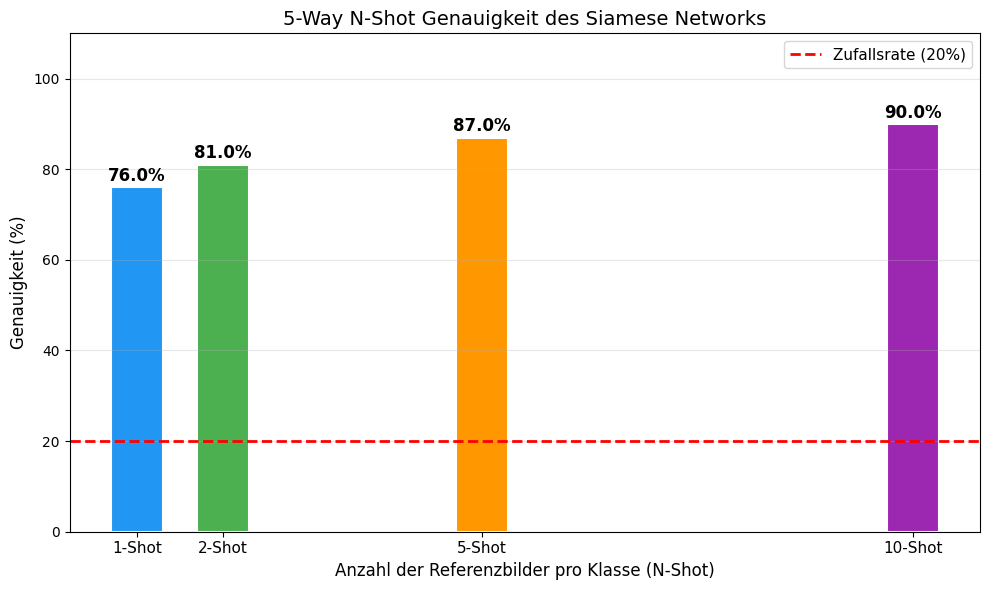

In [20]:
# ─── N-Shot Vergleich plotten ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(n_shot_values, [a * 100 for a in accuracies],
               color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
               edgecolor='white', linewidth=1.5, width=0.6)

# Zufallsrate einzeichnen
ax.axhline(y=100/N_WAY, color='red', linestyle='--', linewidth=2,
           label=f'Zufallsrate ({100/N_WAY:.0f}%)')

# Werte über Balken
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title(f"{N_WAY}-Way N-Shot Genauigkeit des Siamese Networks", fontsize=14)
ax.set_xlabel("Anzahl der Referenzbilder pro Klasse (N-Shot)", fontsize=12)
ax.set_ylabel("Genauigkeit (%)", fontsize=12)
ax.set_xticks(n_shot_values)
ax.set_xticklabels([f"{n}-Shot" for n in n_shot_values], fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("07_n_shot_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Schritt 10: Vergleich mit traditionellen Lernansätzen

Gemäß Aufgabe: Vergleich One-Shot Learning (Siamese Network) mit einem **traditionellen CNN-Klassifikator**, der viele Beispiele pro Klasse benötigt.

**Wichtig:** Beide Modelle werden auf denselben **Trainingsklassen** trainiert und auf denselben **Testklassen** evaluiert.

In [21]:
# ─── Traditioneller CNN-Klassifikator (Baseline) ─────────────────────────────
# Ein normales CNN wird auf den 20 Trainingsklassen trainiert.
# Problem: Es kann NICHT direkt auf neuen Klassen klassifizieren!
# Wir müssen es auf den Testklassen mit ALLEN verfügbaren Bildern neu trainieren.

# Klassifikator für die Testklassen mit K Bildern pro Klasse
def train_traditional_classifier(X_test, y_test, k_per_class=1):
    """
    Trainiert einen traditionellen CNN-Klassifikator auf K Bildern pro Testklasse.
    Dies simuliert, was ein traditionelles Modell benötigen würde.
    """
    # Wähle k Bilder pro Klasse als Trainingsdaten
    train_idx = []
    test_idx  = []

    for cls in np.unique(y_test):
        cls_idx = np.where(y_test == cls)[0]
        train_idx.extend(cls_idx[:k_per_class])
        test_idx.extend(cls_idx[k_per_class:])

    X_tr = X_test[train_idx]
    y_tr = y_test[train_idx]
    X_te = X_test[test_idx]
    y_te = y_test[test_idx]

    if len(X_tr) == 0 or len(X_te) == 0:
        return None

    # Einfaches CNN
    cnn = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=INPUT_SHAPE),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_TEST_CLASSES, activation='softmax')
    ])
    cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    cnn.fit(X_tr, y_tr, epochs=30, verbose=0, batch_size=max(1, len(X_tr)//4))

    _, test_acc = cnn.evaluate(X_te, y_te, verbose=0)
    return test_acc


# Traditionelles CNN bei 1, 2, 5, 10 Bildern pro Klasse
traditional_accuracies = []
print("Trainiere traditionelle CNNs (je einmal pro K)...")

for k in n_shot_values:
    acc = train_traditional_classifier(X_test, y_test, k_per_class=k)
    traditional_accuracies.append(acc if acc else 0)
    print(f"  Traditionelles CNN, {k} Bild(er)/Klasse: {(acc or 0)*100:.2f}%")

print()
print("Vergleich abgeschlossen!")

Trainiere traditionelle CNNs (je einmal pro K)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Traditionelles CNN, 1 Bild(er)/Klasse: 51.58%
  Traditionelles CNN, 2 Bild(er)/Klasse: 63.33%
  Traditionelles CNN, 5 Bild(er)/Klasse: 66.67%
  Traditionelles CNN, 10 Bild(er)/Klasse: 80.00%

Vergleich abgeschlossen!


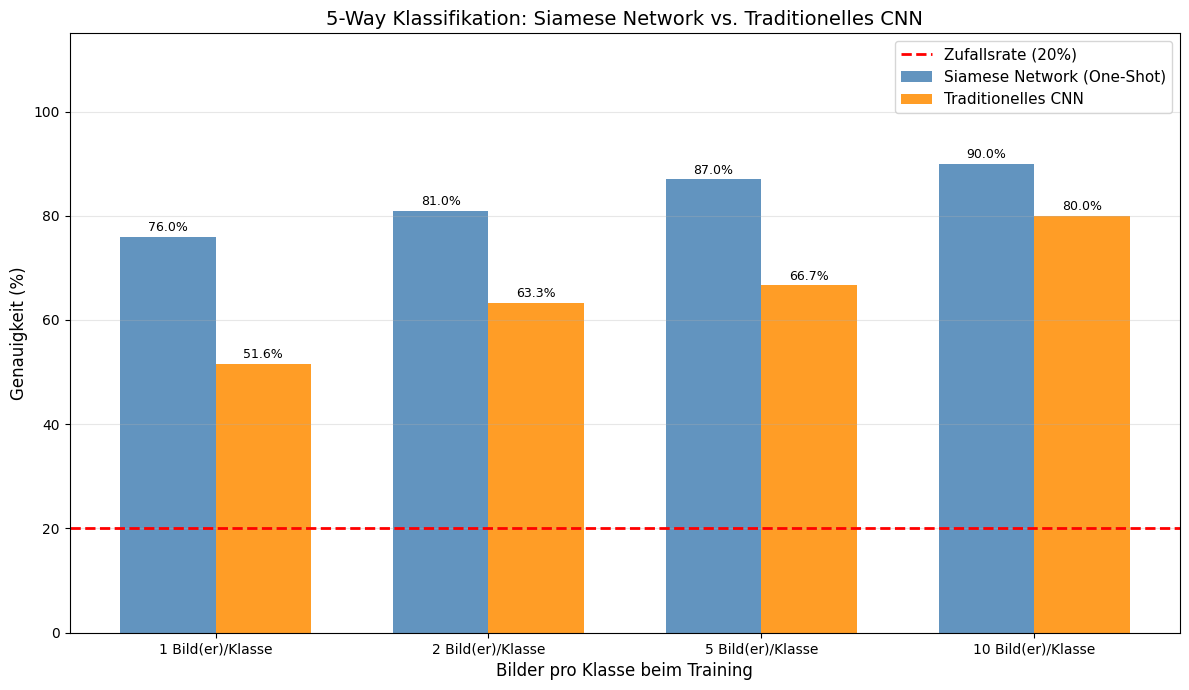

In [22]:
# ─── Vergleich: Siamese vs. Traditionell ─────────────────────────────────────

x = np.arange(len(n_shot_values))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, [a*100 for a in accuracies],             width, label='Siamese Network (One-Shot)', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, [a*100 for a in traditional_accuracies], width, label='Traditionelles CNN',          color='darkorange', alpha=0.85)

ax.axhline(y=100/N_WAY, color='red', linestyle='--', linewidth=2, label=f'Zufallsrate ({100/N_WAY:.0f}%)')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title(f"{N_WAY}-Way Klassifikation: Siamese Network vs. Traditionelles CNN", fontsize=14)
ax.set_xlabel("Bilder pro Klasse beim Training", fontsize=12)
ax.set_ylabel("Genauigkeit (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{k} Bild(er)/Klasse" for k in n_shot_values])
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("08_siamese_vs_traditional.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Schritt 11: Analyse und Diskussion

### Ergebniszusammenfassung

In [23]:
# ─── Ergebniszusammenfassung ──────────────────────────────────────────────────

print("="*60)
print("       ERGEBNISZUSAMMENFASSUNG – ONE-SHOT LEARNING")
print("="*60)
print()
print(f"Datensatz:         Omniglot ({IMG_SIZE}×{IMG_SIZE}px, 1 Kanal)")
print(f"Trainingsklassen:  {N_TRAIN_CLASSES} (Background Split)")
print(f"Testklassen:       {N_TEST_CLASSES}  (Evaluation Split – NEUE Klassen!)")
print(f"N-Way:             {N_WAY}-Way")
print(f"Zufallsrate:       {100/N_WAY:.1f}%")
print()
print("-"*60)
print(f"{'Methode':<35} {'Genauigkeit':>10}")
print("-"*60)
print(f"{'Zufallsrate (Baseline)':<35} {100/N_WAY:>9.1f}%")
print()
for n, acc_siam, acc_trad in zip(n_shot_values, accuracies, traditional_accuracies):
    print(f"{'Siamese Network ' + str(n) + '-Shot':<35} {acc_siam*100:>9.2f}%")
    print(f"{'Traditionelles CNN ' + str(n) + '-Shot':<35} {acc_trad*100:>9.2f}%")
    print()
print("="*60)

       ERGEBNISZUSAMMENFASSUNG – ONE-SHOT LEARNING

Datensatz:         Omniglot (105×105px, 1 Kanal)
Trainingsklassen:  20 (Background Split)
Testklassen:       5  (Evaluation Split – NEUE Klassen!)
N-Way:             5-Way
Zufallsrate:       20.0%

------------------------------------------------------------
Methode                             Genauigkeit
------------------------------------------------------------
Zufallsrate (Baseline)                   20.0%

Siamese Network 1-Shot                  76.00%
Traditionelles CNN 1-Shot               51.58%

Siamese Network 2-Shot                  81.00%
Traditionelles CNN 2-Shot               63.33%

Siamese Network 5-Shot                  87.00%
Traditionelles CNN 5-Shot               66.67%

Siamese Network 10-Shot                 90.00%
Traditionelles CNN 10-Shot              80.00%



---
## Diskussion: Stärken und Schwächen des Ansatzes

### Stärken des Siamese Networks / One-Shot Learnings

1. **Minimale Datenmenge:** Das Modell kann neue Klassen mit nur **einem einzigen Beispiel** erkennen. Traditionelle Modelle benötigen hunderte oder tausende Bilder pro Klasse.

2. **Generalisierung auf neue Klassen:** Das Siamese Network lernt eine allgemeine **Ähnlichkeitsfunktion**, keine spezifische Klasseneinteilung. Es kann auf beliebige neue Klassen angewendet werden, ohne umtrainiert zu werden.

3. **Offene Menge (Open-Set Recognition):** Traditionelle Klassifikatoren können nur Klassen erkennen, auf denen sie trainiert wurden. Das Siamese Network kann prinzipiell mit unbegrenzt vielen Klassen umgehen.

4. **Transfer-Potential:** Die gelernten Embeddings sind oft auf verwandte Domänen übertragbar.

### Schwächen

1. **Geringere Genauigkeit bei mehr Daten:** Wenn viele Beispiele pro Klasse vorhanden sind, übertrifft ein traditionisches CNN das Siamese Network deutlich (siehe N-Shot Vergleich).

2. **Trainingsaufwand:** Das Training mit Bildpaaren ist komplex. Es müssen $O(n^2)$ Paare generiert werden.

3. **Empfindlichkeit gegenüber Variationen:** Bei stark variierenden Stilen (z.B. verschiedene Handschriften) kann die Ähnlichkeit schlechter erkannt werden.

4. **Quadratische Inferenzzeit:** Bei N Klassen werden N Vergleiche benötigt. Für sehr große N kann das langsam werden.

### Fazit

> One-Shot Learning mit Siamese Networks ist besonders wertvoll in Szenarien, in denen **wenige Trainingsdaten** verfügbar sind oder neue Klassen schnell integriert werden müssen – z.B. Gesichtserkennung neuer Personen, medizinische Bildgebung seltener Erkrankungen oder Zeichenerkennung unbekannter Schriften. Bei ausreichend Daten sind traditionelle Ansätze überlegen.

In [25]:
# ─── Finale Zusammenfassung aller Grafiken ────────────────────────────────────

saved_figs = [
    ("01_omniglot_examples.png",     "Omniglot Datensatz-Beispiele"),
    ("02_training_pairs.png",         "Trainingspaare (positiv/negativ)"),
    ("03_training_history.png",       "Trainingsfortschritt"),
    ("04_one_shot_task.png",          "One-Shot Task Visualisierung"),
    ("05_feature_space_pca.png",      "Feature Space (PCA)"),
    ("06_distance_distribution.png",  "Distanzverteilung"),
    ("07_n_shot_comparison.png",      "N-Shot Vergleich"),
    ("08_siamese_vs_traditional.png", "Siamese vs. Traditionell"),
]

print("Gespeicherte Visualisierungen:")
for fname, desc in saved_figs:
    exists = "✅" if os.path.exists(fname) else "❌"
    print(f"  {exists} {fname} – {desc}")

print()
print("Notebook vollständig ausgeführt!")
print(f"   Finale One-Shot Genauigkeit ({N_WAY}-Way): {accuracy*100:.2f}%")

Gespeicherte Visualisierungen:
  ✅ 01_omniglot_examples.png – Omniglot Datensatz-Beispiele
  ✅ 02_training_pairs.png – Trainingspaare (positiv/negativ)
  ✅ 03_training_history.png – Trainingsfortschritt
  ✅ 04_one_shot_task.png – One-Shot Task Visualisierung
  ✅ 05_feature_space_pca.png – Feature Space (PCA)
  ✅ 06_distance_distribution.png – Distanzverteilung
  ✅ 07_n_shot_comparison.png – N-Shot Vergleich
  ✅ 08_siamese_vs_traditional.png – Siamese vs. Traditionell

Notebook vollständig ausgeführt!
   Finale One-Shot Genauigkeit (5-Way): 64.00%
